In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the data
df = pd.read_csv('../data/raw/customer_data.csv')

print("=" * 50)
print("CUSTOMER DATA OVERVIEW")
print("=" * 50)
print(f"\nDataset Shape: {df.shape}")
print(f"Total Customers: {df.shape[0]}")
print(f"\nFirst 5 Rows:")
print(df.head())
print(f"\nData Types:")
print(df.dtypes)
print(f"\nMissing Values:")
print(df.isnull().sum())

CUSTOMER DATA OVERVIEW

Dataset Shape: (1000, 9)
Total Customers: 1000

First 5 Rows:
   customer_id signup_date  age country  total_purchases  total_spent  \
0            1  2023-11-24   56  Canada               19         2476   
1            2  2023-02-27   69  France               30         3109   
2            3  2023-01-13   46      UK                7         3093   
3            4  2023-05-21   32     USA               10         1062   
4            5  2023-05-06   60   India               41         3732   

   last_purchase_days_ago  avg_order_value  is_active  
0                     313              406          1  
1                      49              389          1  
2                     118              253          1  
3                      54              210          0  
4                     138               77          0  

Data Types:
customer_id                int64
signup_date               object
age                        int64
country                   o

In [2]:
print("\n" + "=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
print(df.describe())

print("\n" + "=" * 50)
print("KEY METRICS")
print("=" * 50)
print(f"Average Age: {df['age'].mean():.2f} years")
print(f"Average Total Spent: ${df['total_spent'].mean():.2f}")
print(f"Average Number of Purchases: {df['total_purchases'].mean():.2f}")
print(f"Active Customers: {df['is_active'].sum()} ({df['is_active'].mean()*100:.1f}%)")
print(f"Inactive Customers: {(1-df['is_active']).sum()} ({(1-df['is_active']).mean()*100:.1f}%)")


STATISTICAL SUMMARY
       customer_id          age  total_purchases  total_spent  \
count  1000.000000  1000.000000      1000.000000     1000.000   
mean    500.500000    49.857000        24.363000     2505.241   
std     288.819436    18.114267        13.977718     1368.109   
min       1.000000    18.000000         1.000000      106.000   
25%     250.750000    35.000000        12.000000     1340.250   
50%     500.500000    50.000000        24.000000     2422.000   
75%     750.250000    66.000000        36.000000     3729.250   
max    1000.000000    79.000000        49.000000     4997.000   

       last_purchase_days_ago  avg_order_value    is_active  
count             1000.000000      1000.000000  1000.000000  
mean               180.694000       284.007000     0.688000  
std                105.520382       129.096665     0.463542  
min                  1.000000        50.000000     0.000000  
25%                 89.750000       176.000000     0.000000  
50%                17

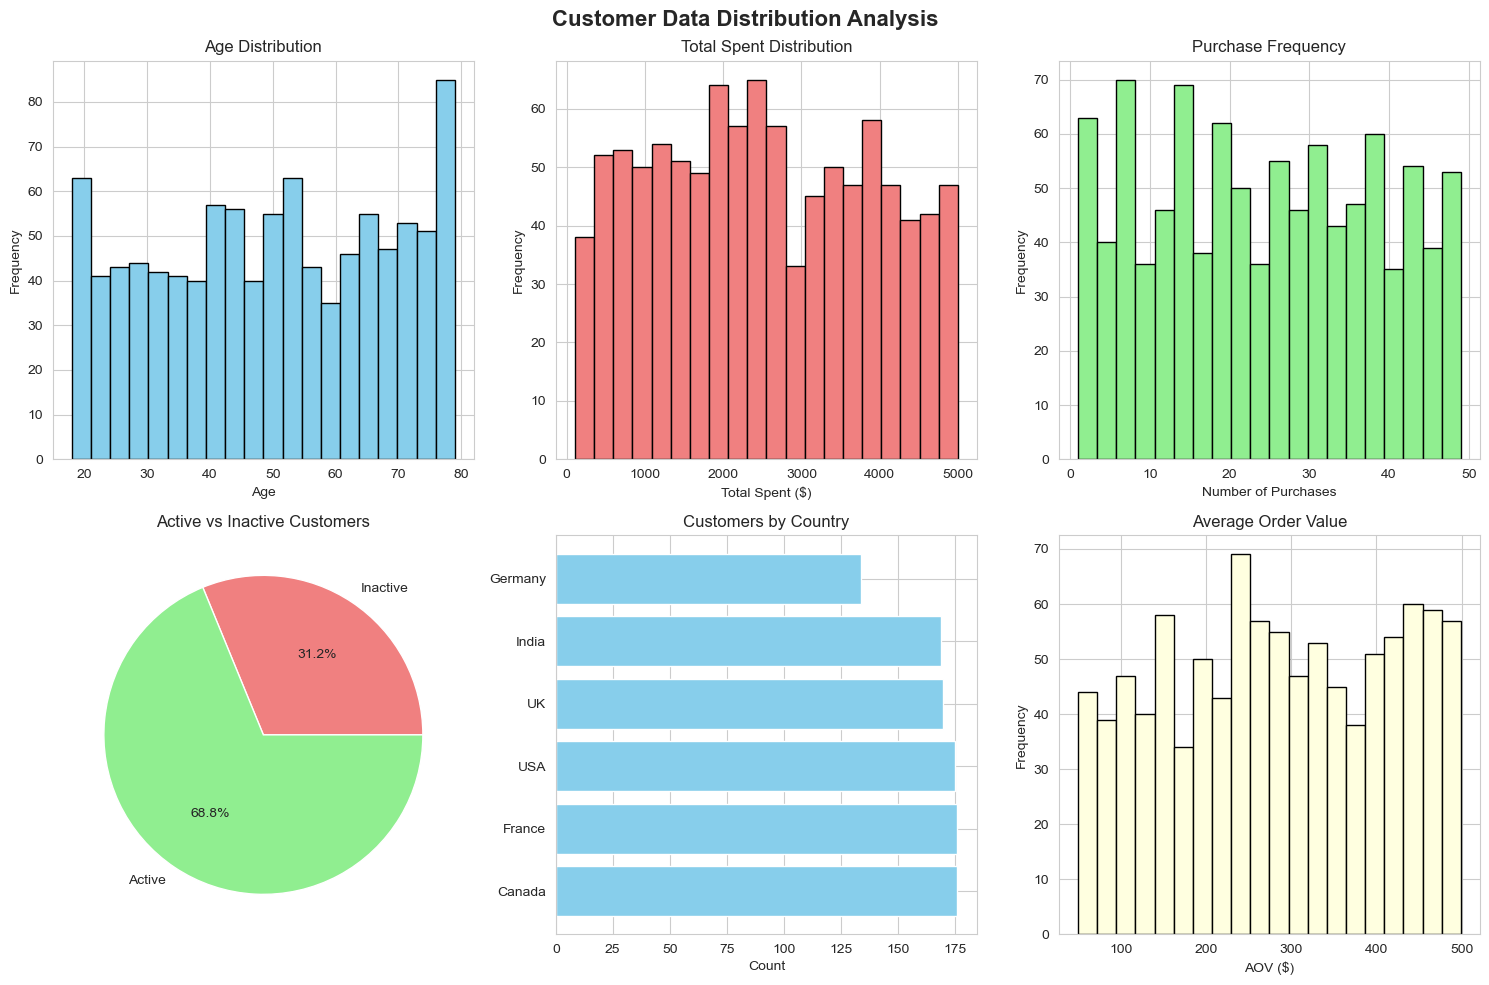

Visualizations created successfully!


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Customer Data Distribution Analysis', fontsize=16, fontweight='bold')

# Age Distribution
axes[0, 0].hist(df['age'], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

# Total Spent Distribution
axes[0, 1].hist(df['total_spent'], bins=20, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Total Spent Distribution')
axes[0, 1].set_xlabel('Total Spent ($)')
axes[0, 1].set_ylabel('Frequency')

# Number of Purchases
axes[0, 2].hist(df['total_purchases'], bins=20, color='lightgreen', edgecolor='black')
axes[0, 2].set_title('Purchase Frequency')
axes[0, 2].set_xlabel('Number of Purchases')
axes[0, 2].set_ylabel('Frequency')

# Active vs Inactive
active_counts = df['is_active'].value_counts()
axes[1, 0].pie([active_counts[0], active_counts[1]], labels=['Inactive', 'Active'], 
               autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'])
axes[1, 0].set_title('Active vs Inactive Customers')

# Country Distribution
country_counts = df['country'].value_counts()
axes[1, 1].barh(country_counts.index, country_counts.values, color='skyblue')
axes[1, 1].set_title('Customers by Country')
axes[1, 1].set_xlabel('Count')

# Average Order Value
axes[1, 2].hist(df['avg_order_value'], bins=20, color='lightyellow', edgecolor='black')
axes[1, 2].set_title('Average Order Value')
axes[1, 2].set_xlabel('AOV ($)')
axes[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Visualizations created successfully!")


CORRELATION ANALYSIS
                        customer_id       age  total_purchases  total_spent  \
customer_id                1.000000  0.000594        -0.007154     0.025777   
age                        0.000594  1.000000         0.021032    -0.040856   
total_purchases           -0.007154  0.021032         1.000000    -0.043106   
total_spent                0.025777 -0.040856        -0.043106     1.000000   
last_purchase_days_ago     0.049572  0.029325        -0.023786     0.009318   
avg_order_value           -0.003812  0.005000        -0.029166     0.057450   
is_active                  0.056518 -0.033811         0.052104    -0.002697   

                        last_purchase_days_ago  avg_order_value  is_active  
customer_id                           0.049572        -0.003812   0.056518  
age                                   0.029325         0.005000  -0.033811  
total_purchases                      -0.023786        -0.029166   0.052104  
total_spent                          

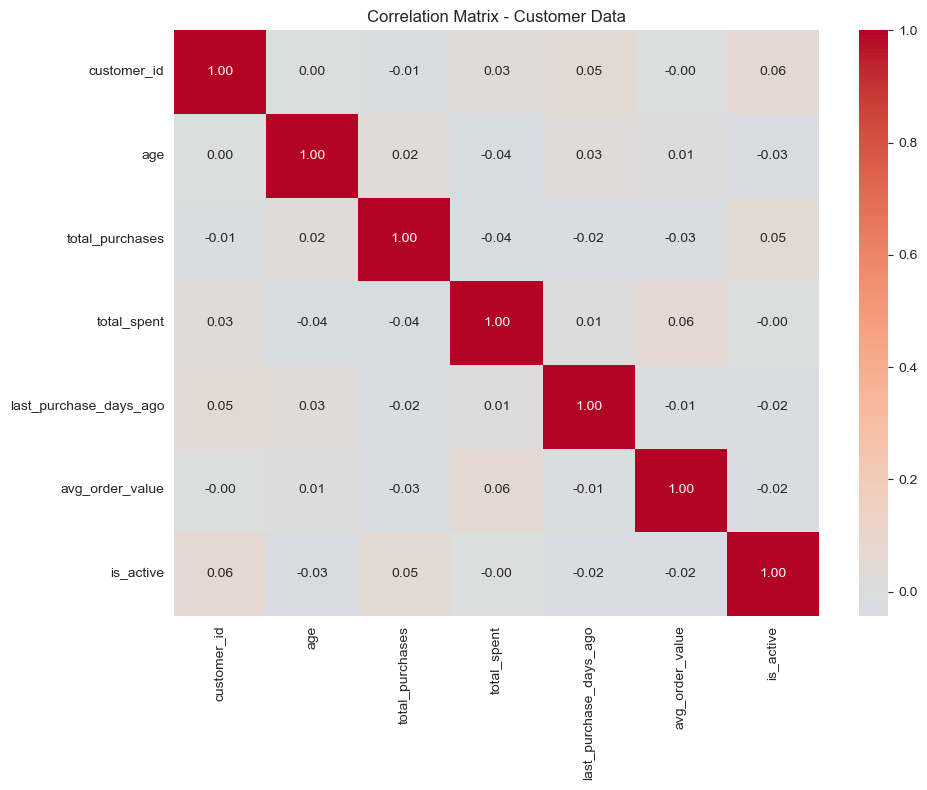

In [4]:
# Correlation Analysis
print("\n" + "=" * 50)
print("CORRELATION ANALYSIS")
print("=" * 50)

numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()
print(correlation)

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix - Customer Data')
plt.tight_layout()
plt.show()